In [225]:
import os
import glob
import re
import xarray as xr
import pandas as pd
import numpy as np
import datetime
import logging
import matplotlib.pyplot as plt

In [226]:
# Configurar logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

In [227]:
# Función para parsear los archivos WCT
def parse_wct_file(file_path):
    """
    Parsea un archivo WCT y extrae sus metadatos y datos.
    
    Args:
        file_path: Ruta al archivo WCT
        
    Returns:
        metadata: Diccionario con los metadatos
        data: DataFrame de pandas con los datos
    """
    metadata = {}
    data_lines = []
    
    try:
        with open(file_path, 'r', errors='replace') as f:
            lines = f.readlines()
        
        if len(lines) < 6:
            logger.error(f"Archivo {file_path} demasiado corto. Debe tener al menos 6 líneas.")
            return None, None
        
        # Extraer metadatos de las primeras líneas
        header_line = lines[0].strip()
        try:
            # Usar expresiones regulares para extraer información
            expocode_match = re.search(r'EXPOCODE\s+(\S+)', header_line)
            metadata['EXPOCODE'] = expocode_match.group(1) if expocode_match else "UNKNOWN"
            
            whp_id_match = re.search(r'WHP-ID\s+(\S+)', header_line)
            metadata['WHP_ID'] = whp_id_match.group(1) if whp_id_match else "UNKNOWN"
            
            date_match = re.search(r'DATE\s+(\S+)', header_line)
            metadata['DATE'] = date_match.group(1) if date_match else "UNKNOWN"
        except Exception as e:
            logger.warning(f"Error al extraer metadatos de la cabecera: {e}. Usando valores predeterminados.")
            metadata['EXPOCODE'] = "UNKNOWN"
            metadata['WHP_ID'] = "UNKNOWN"
            metadata['DATE'] = "UNKNOWN"
        
        station_line = lines[1].strip()
        try:
            stnnbr_match = re.search(r'STNNBR\s+(\d+)', station_line)
            metadata['STNNBR'] = int(stnnbr_match.group(1)) if stnnbr_match else -9
            
            castno_match = re.search(r'CASTNO\s+(\d+)', station_line)
            metadata['CASTNO'] = int(castno_match.group(1)) if castno_match else -9
            
            records_match = re.search(r'NO\.\s+RECORDS=\s+(\d+)', station_line)
            metadata['NO_RECORDS'] = int(records_match.group(1)) if records_match else -9
        except Exception as e:
            logger.warning(f"Error al extraer metadatos de la línea de estación: {e}. Usando valores predeterminados.")
            metadata['STNNBR'] = -9
            metadata['CASTNO'] = -9
            metadata['NO_RECORDS'] = -9
        
        instrument_line = lines[2].strip()
        try:
            instrument_match = re.search(r'INSTRUMENT NO\.\s+(\d+)', instrument_line)
            metadata['INSTRUMENT_NO'] = int(instrument_match.group(1)) if instrument_match else -9
            
            sampling_match = re.search(r'SAMPLING RATE\s+(\d+\.?\d*)', instrument_line)
            metadata['SAMPLING_RATE'] = float(sampling_match.group(1)) if sampling_match else -9.0
        except Exception as e:
            logger.warning(f"Error al extraer metadatos de la línea de instrumento: {e}. Usando valores predeterminados.")
            metadata['INSTRUMENT_NO'] = -9
            metadata['SAMPLING_RATE'] = -9.0
        
        # Determinar dónde comienzan los datos
        data_start = 0
        column_names = []
        
        for i, line in enumerate(lines):
            stripped_line = line.strip()
            if stripped_line.startswith('*******'):
                data_start = i + 1
                # Las columnas están en la línea antes de los asteriscos
                if i > 0:
                    column_names = lines[i-2].strip().split()
                break
        
        if not column_names:
            # Intento alternativo para encontrar nombres de columnas
            for i, line in enumerate(lines):
                stripped_line = line.strip()
                if 'CTDPRS' in stripped_line and 'CTDTMP' in stripped_line:
                    column_names = stripped_line.split()
                    break
        
        if not column_names:
            logger.error(f"No se pudieron encontrar los nombres de las columnas en {file_path}")
            return None, None
        
        if data_start == 0:
            logger.error(f"No se pudo determinar dónde comienzan los datos en {file_path}")
            return None, None
        
        # Leer los datos en un DataFrame
        for line in lines[data_start:]:
            stripped_line = line.strip()
            if not stripped_line:  # Saltar líneas vacías
                continue
                
            values = stripped_line.split()
            if len(values) == len(column_names):
                data_lines.append(values)
        
        if not data_lines:
            logger.error(f"No se encontraron datos válidos en {file_path}")
            return None, None
        
        # Convertir a DataFrame y asegurar que los valores son numéricos
        data = pd.DataFrame(data_lines, columns=column_names)
        for col in data.columns:
            data[col] = pd.to_numeric(data[col], errors='coerce')
        
        # Añadir nombre de archivo como referencia
        metadata['FILENAME'] = os.path.basename(file_path)
        
        return metadata, data
        
    except Exception as e:
        logger.error(f"Error al procesar {file_path}: {e}")
        return None, None


# Inicio

## Lee los ficheros del este

In [228]:
input_dir = "./data/P03e_wct/"
# Buscar todos los archivos WCT
wct_files = sorted(glob.glob(os.path.join(input_dir, "*.WCT")))
logger.info(f"Encontrados {len(wct_files)} archivos .WCT para procesar")    

2025-04-07 08:20:03,728 - INFO - Encontrados 106 archivos .WCT para procesar


In [229]:
all_metadata = []
all_data = []
station_var=np.array([])
date_var=np.array([])
ctd_temperature=np.array([])
pressure=np.array([])
ctd_salinity=np.array([])

N_LEVELS=3210
N_PROF=len(wct_files)

In [230]:
i1=0
print(wct_files[i1])
metadata, data = parse_wct_file(wct_files[i1])
station_var = np.append(station_var,metadata['STNNBR'])
date_var = np.append(station_var,metadata['DATE'])

press=data.CTDPRS.to_numpy()
pressure=np.pad(press, (0, N_LEVELS-len(press)), mode='constant', constant_values=np.nan)
temp=data.CTDTMP.to_numpy()
ctd_temperature=np.pad(temp, (0, N_LEVELS-len(temp)), mode='constant', constant_values=np.nan)
salt=data.CTDSAL.to_numpy()
ctd_salinity=np.pad(salt, (0, N_LEVELS-len(salt)), mode='constant', constant_values=np.nan)

./data/P03e_wct\S001C05.WCT


In [231]:
# Initialize arrays before the loop
n_profiles = len(wct_files)
# Correct dimensions: (N_PROF, N_LEVELS)
pressure = np.full((N_PROF, N_LEVELS), np.nan)
ctd_temperature = np.full((N_PROF, N_LEVELS), np.nan)
ctd_salinity = np.full((N_PROF, N_LEVELS), np.nan)
station_var = np.array([])
date_var = np.array([])

for i1 in range(len(wct_files)):  # Loop over profiles
    metadata, data = parse_wct_file(wct_files[i1])
    if metadata is None or data is None:
        continue  # Skip files with errors

    # Assign metadata
    station_var = np.append(station_var, metadata['STNNBR'])
    date_var = np.append(date_var, metadata['DATE'])

    # Assign data to the correct profile index (row)
    press = data.CTDPRS.to_numpy()
    pressure[i1, :len(press)] = press  # Assign to row i1

    temp = data.CTDTMP.to_numpy()
    ctd_temperature[i1, :len(temp)] = temp  # Assign to row i1

    salt = data.CTDSAL.to_numpy()
    ctd_salinity[i1, :len(salt)] = salt  # Assign to row i1

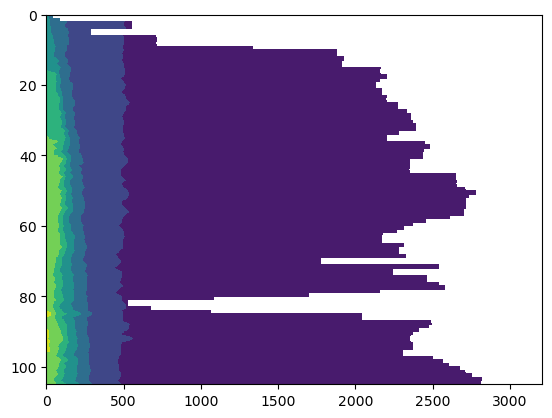

In [232]:
fig, ax = plt.subplots()
ax.contourf(ctd_temperature);
ax.invert_yaxis()
#ax.set_ylim((0,30))
#ax.set_xlim((33.25,35.75))


## Lee los ficheros del west

In [233]:
input_dir = "./data/P03w_wct"
# Buscar todos los archivos WCT
wct_files = sorted(glob.glob(os.path.join(input_dir, "*.WCT")))
logger.info(f"Encontrados {len(wct_files)} archivos .WCT para procesar")    

2025-04-07 08:20:11,631 - INFO - Encontrados 110 archivos .WCT para procesar


In [234]:
# Loop over west files and append data
for i1 in range(len(wct_files)):
    metadata, data = parse_wct_file(wct_files[i1])
    if metadata is None or data is None:
        continue  # Skip files with errors

    # Append metadata
    station_var = np.append(station_var, metadata['STNNBR'])
    date_var = np.append(date_var, metadata['DATE'])

    # Append data to the correct profile index
    press = data.CTDPRS.to_numpy()
    pressure_prof = np.pad(press, (0, N_LEVELS - len(press)), mode='constant', constant_values=np.nan)
    pressure = np.vstack((pressure, pressure_prof))  # Append as a new row

    temp = data.CTDTMP.to_numpy()
    ctd_temperature_prof = np.pad(temp, (0, N_LEVELS - len(temp)), mode='constant', constant_values=np.nan)
    ctd_temperature = np.vstack((ctd_temperature, ctd_temperature_prof))

    salt = data.CTDSAL.to_numpy()
    ctd_salinity_prof = np.pad(salt, (0, N_LEVELS - len(salt)), mode='constant', constant_values=np.nan)
    ctd_salinity = np.vstack((ctd_salinity, ctd_salinity_prof))

In [235]:
press

array([  2.,   4.,   6.,   8.,  10.,  12.,  14.,  16.,  18.,  20.,  22.,
        24.,  26.,  28.,  30.,  32.,  34.,  36.,  38.,  40.,  42.,  44.,
        46.,  48.,  50.,  52.,  54.,  56.,  58.,  60.,  62.,  64.,  66.,
        68.,  70.,  72.,  74.,  76.,  78.,  80.,  82.,  84.,  86.,  88.,
        90.,  92.,  94.,  96.,  98., 100., 102., 104., 106., 108., 110.,
       112., 114., 116., 118., 120., 122., 124., 126., 128., 130., 132.,
       134., 136., 138., 140., 142., 144., 146., 148., 150., 152., 154.,
       156., 158., 160., 162., 164., 166., 168., 170., 172., 174., 176.,
       178., 180., 182., 184., 186., 188., 190., 192., 194., 196., 198.,
       200., 202.])

In [236]:
ctd_temperature_xr= xr.DataArray(ctd_temperature)
ctd_salinity_xr= xr.DataArray(ctd_salinity)
pressure_xr= xr.DataArray(pressure)

In [237]:
ctd_temperature_xr = np.where(ctd_temperature_xr==-9, np.nan, ctd_temperature_xr)
ctd_salinity_xr = np.where(ctd_salinity_xr==-9, np.nan, ctd_salinity_xr)
pressure_xr= np.where(pressure_xr==-9, np.nan, pressure_xr)


(33.25, 35.75)

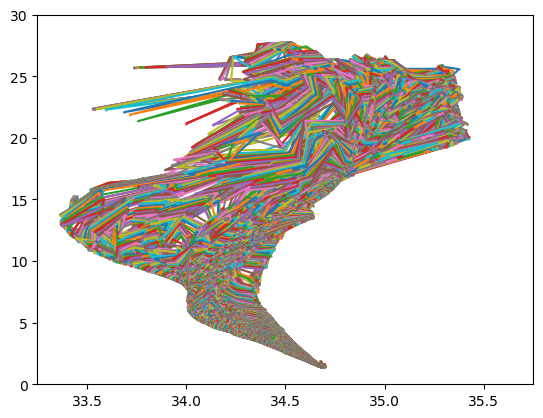

In [238]:
fig, ax = plt.subplots()

ax.plot(ctd_salinity_xr, ctd_temperature_xr,
         marker='.',
         markersize=1,
         linestyle='-');
ax.set_ylim((0,30))
ax.set_xlim((33.25,35.75))

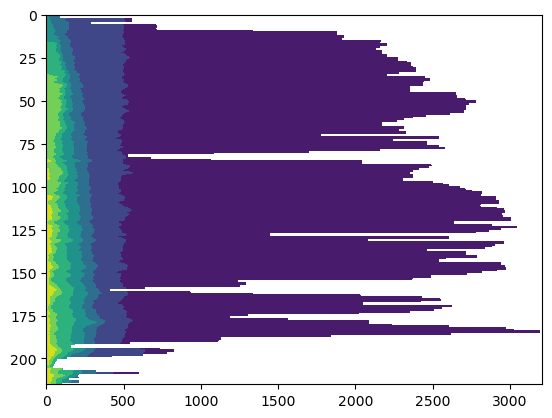

In [239]:
fig, ax = plt.subplots()
ax.contourf(ctd_temperature_xr);
ax.invert_yaxis()
#ax.set_ylim((0,30))
#ax.set_xlim((33.25,35.75))



In [240]:
metadata=pd.read_fwf('P03e.txt')

In [241]:
LON=metadata.LONGITUDE.values
LAT=metadata.LATITUDE.values
STNNBR=metadata.STNNBR

In [242]:
longitude_e=np.array([])
latitude_e=np.array([])
station_e=np.array([])


In [243]:
for i1 in np.arange(0,len(LAT)):
    latitude_e = np.append(latitude_e, float(LAT[i1][0:2])+float(LAT[i1][3:8])/60)
    longitude_e = np.append(longitude_e, -float(LON[i1][0:3])-float(LON[i1][4:8])/60)
    station_e = np.append(station_e,float(STNNBR[i1]))    
    

In [244]:
metadata=pd.read_fwf('P03w.txt')

In [245]:
LON=metadata.LONGITUDE.values
LAT=metadata.LATITUDE.values
STNNBR=metadata.STNNBR

In [246]:
longitude_w=np.array([])
latitude_w=np.array([])
station_w=np.array([])


In [247]:
for i1 in np.arange(0,len(LAT)):
    latitude_w = np.append(latitude_w, float(LAT[i1][0:2])+float(LAT[i1][3:8])/60)
    longitude_w = np.append(longitude_w,float(LON[i1][0:3])+float(LON[i1][4:8])/60)
    station_w = np.append(station_w,float(STNNBR[i1]))    
    

In [248]:
# Primero obtengo los valores únicos de station 
stations = np.unique(np.concatenate([station_e, station_w]))

# Inicializo las nuevas variables
longitude_f = np.array([])
latitude_f = np.array([])
station_f = np.array([])

# Para cada estación, busco y concateno los datos correspondientes
for st in stations:
    # Busco índices donde station_e es igual a la estación actual
    idx_e = np.where(station_e == st)[0]
    if len(idx_e) > 0:
        longitude_f = np.append(longitude_f, longitude_e[idx_e])
        latitude_f = np.append(latitude_f, latitude_e[idx_e])
        station_f = np.append(station_f, station_e[idx_e])
    
    # Busco índices donde station_w es igual a la estación actual
    idx_w = np.where(station_w == st)[0]
    if len(idx_w) > 0:
        longitude_f = np.append(longitude_f, longitude_w[idx_w])
        latitude_f = np.append(latitude_f, latitude_w[idx_w])
        station_f = np.append(station_f, station_w[idx_w])


(-180.0, 180.0)

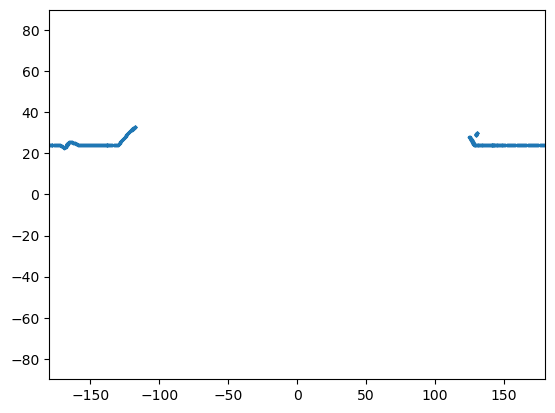

In [249]:
fig, ax = plt.subplots()
ax.scatter(longitude_f,latitude_f, s=2);
ax.set_ylim((-90,90))
ax.set_xlim((-180,180))

In [250]:
station_f_dict = {float(val): idx for idx, val in enumerate(station_f)}

# Crear arrays para almacenar las coordenadas de longitud y latitud para station_var
longitude_var = np.full(station_var.shape, np.nan)
latitude_var = np.full(station_var.shape, np.nan)

# Para cada estación en station_var, buscar su correspondiente en station_f
# y asignar las coordenadas de longitud y latitud
for i, station in enumerate(station_var):
    if station in station_f_dict:
        idx = station_f_dict[station]
        longitude_var[i] = longitude_f[idx]
        latitude_var[i] = latitude_f[idx]

In [251]:
# First, let's verify the shapes of all arrays
print(f"ctd_temperature shape: {ctd_temperature.shape}")
print(f"ctd_salinity shape: {ctd_salinity.shape}")
print(f"pressure shape: {pressure.shape}")
print(f"date_var shape: {date_var.shape}")
print(f"latitude_var shape: {latitude_var.shape}")
print(f"longitude_var shape: {longitude_var.shape}")
print(f"longitude_var length: {len(longitude_var)}")

# Then create the Dataset with consistent dimensions
ds = xr.Dataset(
    data_vars = dict(
        ctd_temperature = (["N_PROF", "N_LEVELS"], ctd_temperature, {
            "whp_name": "CTDTMP",
            "whp_units": "ITS-90",
            "standard_name": "sea_water_temperature",
            "units": "degC",
            "reference_scale": "ITS-90"
        }),
        ctd_salinity = (["N_PROF", "N_LEVELS"], ctd_salinity, {
            "whp_name": "CTDSAL",
            "whp_units": "PSS-78",
            "standard_name": "sea_water_practical_salinity",
            "units": "1",
            "reference_scale": "PSS-78"
        }),
    ),
    coords = dict(
        date = ("N_PROF", date_var),
        latitude = ("N_PROF", latitude_var),
        longitude = ("N_PROF", longitude_var), 
        pressure = (["N_PROF", "N_LEVELS"], pressure, {
            "whp_name": "CTDPRS",
            "whp_units": "dbars",
            "standard_name": "sea_water_pressure",
            "units": "dbars"
        })
    )
)

ctd_temperature shape: (216, 3210)
ctd_salinity shape: (216, 3210)
pressure shape: (216, 3210)
date_var shape: (216,)
latitude_var shape: (216,)
longitude_var shape: (216,)
longitude_var length: 216


In [252]:
# Guardar como archivo NetCDF
output_file = "1985_31TTTPS24_2.nc"
ds.to_netcdf(output_file)
print(f"NetCDF file created: {output_file}") 

NetCDF file created: 1985_31TTTPS24_2.nc
